# UD Sentence Max-DD and Treebank Typological Features

This notebook demonstrates the extraction and analysis of **sentence-level maximum dependency distance (max-DD)** data and **treebank-level typological features** from Universal Dependencies treebanks (UD v2.17).

**What this artifact does:**
- Extracts max-DD, normalized max-DD, and non-projectivity flags for sentences of specific lengths (n=10,12,14,16,18,20)
- Computes treebank-level features: morphological richness, head-direction ratio, word-order entropy (Levshina 2019), non-projectivity rate
- Covers 238 qualifying treebanks across 122 unique languages

The demo loads pre-computed results and demonstrates the core processing functions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import math
import os
from collections import Counter, defaultdict
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-42dac1-word-order-entropy-predicts-ordinal-tail/main/dataset_iter1_ud_sentence_max/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples from dataset '{data['datasets'][0]['dataset']}'")
treebank_rows = [e for e in examples if e.get("metadata_row_type") == "treebank"]
sentence_rows = [e for e in examples if e.get("metadata_row_type") == "sentence"]
print(f"  Treebank-level rows: {len(treebank_rows)}")
print(f"  Sentence-level rows: {len(sentence_rows)}")

Loaded 48 examples from dataset 'ud_maxdd_typology'
  Treebank-level rows: 8
  Sentence-level rows: 40


## Configuration

Tunable parameters controlling treebank filtering and sentence binning thresholds.

In [5]:
# --- Config: tunable parameters ---
# Sentence length bins to analyze
TARGET_BINS = frozenset({10, 12, 14, 16, 18, 20})
# Minimum total sentences for a treebank to qualify
MIN_TOTAL_SENTENCES = 500  # original: 500
# Minimum sentences per bin to qualify
MIN_PER_BIN = 50  # original: 50
# Number of top relations to display in per-relation entropy
N_TOP_RELATIONS = 20  # original: 20

## Sentence-Level Processing

The `process_sentence` function extracts dependency distances, tree edges, morphological feature counts, and non-projectivity from a single UD sentence.

In [6]:
def process_sentence(
    tokens: list[str],
    heads_str: list[str],
    deprels: list[str],
    feats_list: list[str | None],
) -> dict[str, Any] | None:
    """Extract features from a single sentence. Returns None if invalid."""
    n = len(tokens)
    if n < 2 or len(heads_str) != n:
        return None

    # Convert heads to int, validate
    heads: list[int] = []
    for h in heads_str:
        if h is None or "-" in str(h):
            return None  # MWT contamination
        try:
            heads.append(int(h))
        except (ValueError, TypeError):
            return None

    # Validate head range
    for h in heads:
        if h < 0 or h > n:
            return None

    # Dependency distances & tree edges
    dep_distances: list[int] = []
    tree_edges: list[tuple[int, int]] = []
    head_directions: list[tuple[str, bool]] = []

    for i, h in enumerate(heads):
        dep_pos = i + 1
        tree_edges.append((h, dep_pos))
        if h == 0:
            continue  # root -- no dependency distance
        dd = abs(dep_pos - h)
        dep_distances.append(dd)
        head_directions.append((deprels[i], h < dep_pos))

    if not dep_distances:
        return None

    max_dd = max(dep_distances)
    max_dd_norm = round(max_dd / (n - 1), 6)

    # Morphological feature counts per token
    feat_counts: list[int] = []
    for f in feats_list:
        if f is None or f == "_" or f == "":
            feat_counts.append(0)
        else:
            feat_counts.append(len(f.split("|")))

    # Non-projectivity check (inline for speed)
    is_nonproj = False
    arcs = [(min(h, d), max(h, d)) for h, d in tree_edges if h != 0]
    n_arcs = len(arcs)
    for i in range(n_arcs):
        a1_l, a1_r = arcs[i]
        for j in range(i + 1, n_arcs):
            a2_l, a2_r = arcs[j]
            if (a1_l < a2_l < a1_r < a2_r) or (a2_l < a1_l < a2_r < a1_r):
                is_nonproj = True
                break
        if is_nonproj:
            break

    return {
        "n": n,
        "max_dd": max_dd,
        "max_dd_normalized": max_dd_norm,
        "dep_distances": dep_distances,
        "tree_edges": tree_edges,
        "feat_counts": feat_counts,
        "head_directions": head_directions,
        "is_nonprojective": is_nonproj,
    }

### Demo: Process a Single Sentence

Demonstrate `process_sentence` on a synthetic English sentence: *"The cat sat on the mat"* with UD-style dependency annotations.

In [7]:
# "The cat sat on the mat" with UD-style annotations
demo_tokens = ["The", "cat", "sat", "on", "the", "mat"]
demo_heads  = ["2",   "3",  "0",  "6",  "6",  "3"]
demo_deprels = ["det", "nsubj", "root", "case", "det", "obl"]
demo_feats  = ["Definite=Def|PronType=Art", "Number=Sing", "Mood=Ind|Tense=Past|VerbForm=Fin",
               None, "Definite=Def|PronType=Art", "Number=Sing"]

result = process_sentence(demo_tokens, demo_heads, demo_deprels, demo_feats)
print("Sentence:", " ".join(demo_tokens))
print(f"  Length (n):           {result['n']}")
print(f"  Max dep. distance:    {result['max_dd']}")
print(f"  Normalized max DD:    {result['max_dd_normalized']}")
print(f"  Dep. distances:       {result['dep_distances']}")
print(f"  Tree edges (h->d):    {result['tree_edges']}")
print(f"  Non-projective:       {result['is_nonprojective']}")
print(f"  Feat counts/token:    {result['feat_counts']}")
print(f"  Head directions:      {result['head_directions']}")

Sentence: The cat sat on the mat
  Length (n):           6
  Max dep. distance:    3
  Normalized max DD:    0.6
  Dep. distances:       [1, 1, 2, 1, 3]
  Tree edges (h->d):    [(2, 1), (3, 2), (0, 3), (6, 4), (6, 5), (3, 6)]
  Non-projective:       False
  Feat counts/token:    [2, 1, 3, 0, 2, 1]
  Head directions:      [('det', False), ('nsubj', False), ('case', False), ('det', False), ('obl', True)]


## Treebank-Level Feature Computation

Aggregates sentence-level data into treebank-level typological features: morphological richness, head-direction ratio, frequency-weighted word-order entropy (Levshina 2019), and non-projectivity rate.

In [8]:
def compute_treebank_features(
    all_feat_counts: list[int],
    all_head_directions: list[tuple[str, bool]],
    n_nonproj_sentences: int,
    n_total_sentences: int,
    tokens_with_feats: int,
    total_tokens: int,
) -> dict[str, Any]:
    """Compute treebank-level typological features from aggregated sentence data."""

    # 5a. Morphological richness
    morph_richness = round(sum(all_feat_counts) / max(total_tokens, 1), 4)

    # 5b. Feature annotation completeness
    feat_completeness = round(tokens_with_feats / max(total_tokens, 1), 4)

    # 5c. Head-direction ratio
    if all_head_directions:
        hb_count = sum(1 for _, is_hbd in all_head_directions if is_hbd)
        head_direction_ratio = round(hb_count / len(all_head_directions), 4)
    else:
        head_direction_ratio = 0.5

    # 5d. Word-order entropy (Levshina 2019)
    rel_counts: dict[str, Counter] = defaultdict(Counter)
    for deprel, is_hbd in all_head_directions:
        rel_counts[deprel][is_hbd] += 1

    rel_entropies: dict[str, float] = {}
    rel_token_counts: dict[str, int] = {}
    for deprel, counts in rel_counts.items():
        # Exclude punct and root relations
        if deprel in ("punct", "root"):
            continue
        total = counts[True] + counts[False]
        # Exclude relations with < 10 tokens
        if total < 10:
            continue
        rel_token_counts[deprel] = total
        if counts[True] == 0 or counts[False] == 0:
            rel_entropies[deprel] = 0.0
        else:
            p = counts[True] / total
            rel_entropies[deprel] = round(-p * math.log2(p) - (1 - p) * math.log2(1 - p), 6)

    total_rel_tokens = sum(rel_token_counts.values())
    if total_rel_tokens > 0:
        word_order_entropy = round(
            sum(rel_entropies[r] * rel_token_counts[r] / total_rel_tokens for r in rel_entropies),
            4,
        )
    else:
        word_order_entropy = 0.0

    # 5e. Non-projectivity rate
    nonprojectivity_rate = round(n_nonproj_sentences / max(n_total_sentences, 1), 4)

    # Per-relation entropy (top relations for output)
    top_rels = dict(sorted(rel_entropies.items(), key=lambda x: -rel_token_counts.get(x[0], 0))[:N_TOP_RELATIONS])

    return {
        "morph_richness": morph_richness,
        "feat_completeness": feat_completeness,
        "head_direction_ratio": head_direction_ratio,
        "word_order_entropy": word_order_entropy,
        "nonprojectivity_rate": nonprojectivity_rate,
        "per_relation_entropy": top_rels,
    }

print("compute_treebank_features() defined.")

compute_treebank_features() defined.


## Validation

Run sanity checks on the loaded data: verify max-DD ranges, normalized values, and treebank-level feature bounds.

In [9]:
def validate_output(examples: list[dict]) -> None:
    """Run sanity checks on the output."""
    sentence_rows_v = [e for e in examples if e.get("metadata_row_type") == "sentence"]
    treebank_rows_v = [e for e in examples if e.get("metadata_row_type") == "treebank"]

    print(f"Validation: {len(sentence_rows_v)} sentence rows, {len(treebank_rows_v)} treebank rows")

    # Sentence-level checks
    bad_dd = 0
    bad_norm = 0
    for s in sentence_rows_v:
        n = s["metadata_sentence_length"]
        dd = s["metadata_max_dd"]
        norm = s["metadata_max_dd_normalized"]
        if not (1 <= dd <= n - 1):
            bad_dd += 1
        if not (0 < norm <= 1.0):
            bad_norm += 1
    if bad_dd:
        print(f"  WARNING: {bad_dd} sentences with max_dd out of [1, n-1]")
    if bad_norm:
        print(f"  WARNING: {bad_norm} sentences with normalized max_dd out of (0, 1]")

    # Treebank-level checks
    for t in treebank_rows_v:
        hdr = t["metadata_head_direction_ratio"]
        woe = t["metadata_word_order_entropy"]
        mr = t["metadata_morph_richness"]
        if not (0 <= hdr <= 1):
            print(f"  WARNING: {t['metadata_treebank_id']}: head_direction_ratio={hdr} out of [0,1]")
        if not (0 <= woe <= 1):
            print(f"  WARNING: {t['metadata_treebank_id']}: word_order_entropy={woe} out of [0,1]")
        if mr < 0:
            print(f"  WARNING: {t['metadata_treebank_id']}: morph_richness={mr} < 0")

    # Bin distribution
    bin_counts: Counter = Counter()
    for s in sentence_rows_v:
        bin_counts[s["metadata_length_bin"]] += 1
    for b in sorted(bin_counts):
        print(f"  Bin {b}: {bin_counts[b]} sentences")

    print("Validation complete.")

validate_output(examples)

Validation: 40 sentence rows, 8 treebank rows
  Bin 10: 8 sentences
  Bin 12: 6 sentences
  Bin 14: 8 sentences
  Bin 16: 6 sentences
  Bin 18: 6 sentences
  Bin 20: 6 sentences
Validation complete.


## Treebank Summary Table

Display the key typological features for each treebank in the demo data.

In [10]:
# Print treebank summary table
header = f"{'Treebank':<20} {'Language':<18} {'Modality':<9} {'Morph.R':>7} {'HDR':>6} {'WOE':>6} {'NonProj':>7} {'MeanDD':>7} {'N_Sent':>7}"
print(header)
print("-" * len(header))
for t in treebank_rows:
    print(f"{t['metadata_treebank_id']:<20} "
          f"{t['metadata_language']:<18} "
          f"{t['metadata_modality']:<9} "
          f"{t['metadata_morph_richness']:>7.3f} "
          f"{t['metadata_head_direction_ratio']:>6.3f} "
          f"{t['metadata_word_order_entropy']:>6.3f} "
          f"{t['metadata_nonprojectivity_rate']:>7.3f} "
          f"{t['metadata_mean_dd_all']:>7.3f} "
          f"{t['metadata_n_sentences_total']:>7d}")

Treebank             Language           Modality  Morph.R    HDR    WOE NonProj  MeanDD  N_Sent
-----------------------------------------------------------------------------------------------
hbo_ptnk             Ancient-Hebrew     written     1.795  0.560  0.215   0.008   3.611    5608
hy_bsut              Armenian           spoken      2.800  0.373  0.418   0.063   2.929    2523
ca_ancora            Catalan            written     1.752  0.427  0.298   0.056   3.328   16678
zh_pud               Chinese            written     0.149  0.404  0.239   0.020   3.290    1000
azz_itml             Highland-Puebla-Nahuatl written     1.543  0.496  0.466   0.020   2.079    1260
ja_gsdluw            Japanese           written     0.006  0.572  0.013   0.003   2.339    8100
ru_pud               Russian            written     2.618  0.455  0.286   0.023   2.914    1000
eme_tudet            Teko               written     1.295  0.477  0.768   0.002   1.359     913


## Visualization

Plot the key typological features across treebanks and the distribution of max-DD values across sentence length bins.

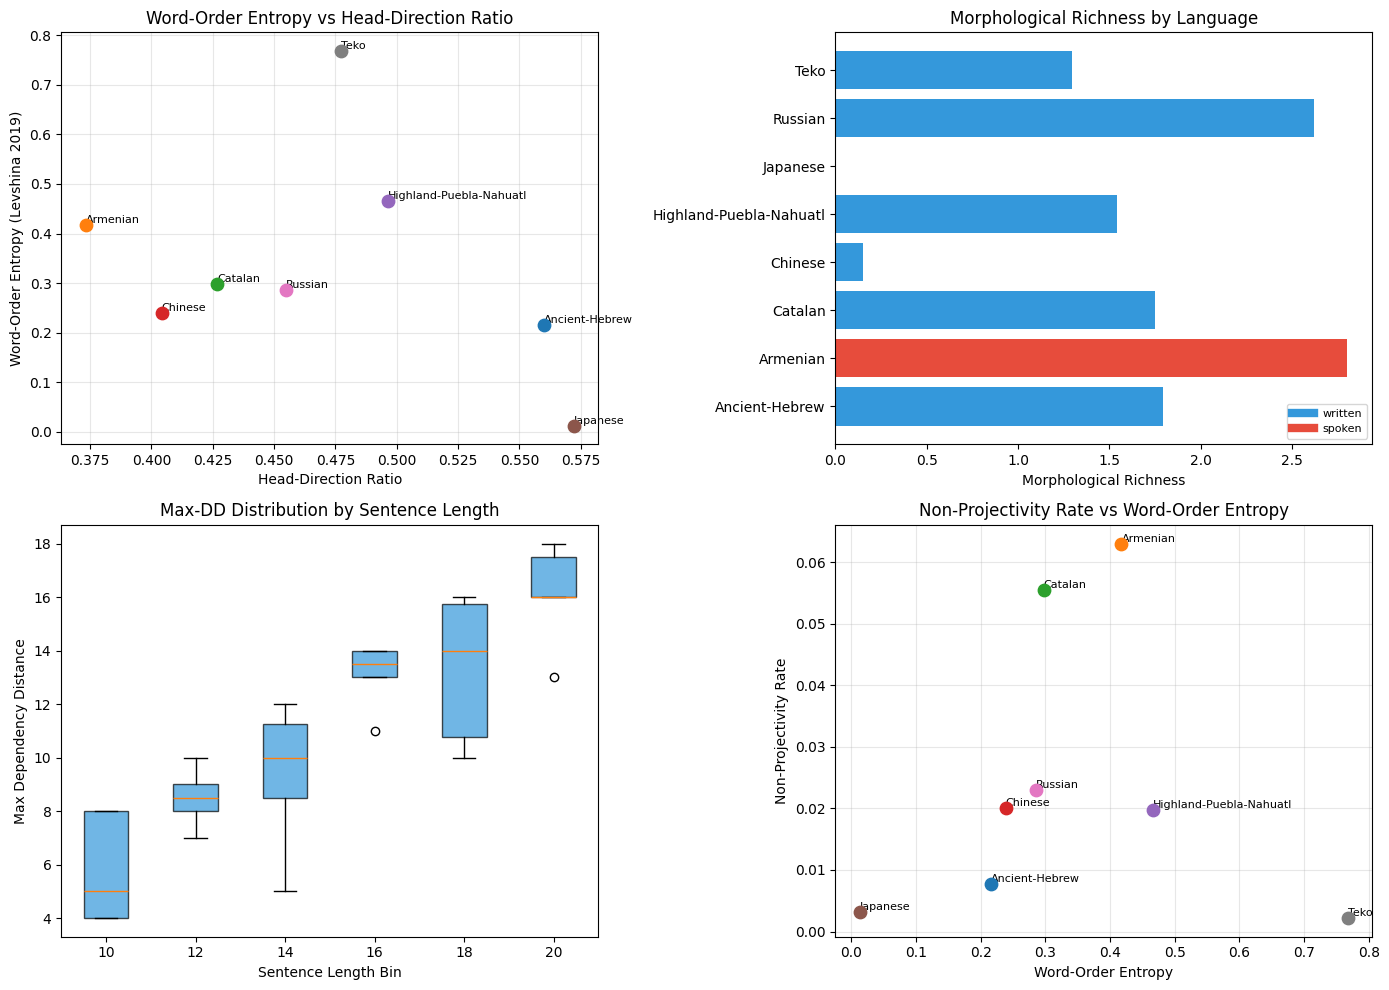

Visualization saved to demo_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Word-Order Entropy vs Head-Direction Ratio ---
ax = axes[0, 0]
for t in treebank_rows:
    ax.scatter(t["metadata_head_direction_ratio"], t["metadata_word_order_entropy"],
               s=80, zorder=5)
    ax.annotate(t["metadata_language"], (t["metadata_head_direction_ratio"], t["metadata_word_order_entropy"]),
                fontsize=8, ha="left", va="bottom")
ax.set_xlabel("Head-Direction Ratio")
ax.set_ylabel("Word-Order Entropy (Levshina 2019)")
ax.set_title("Word-Order Entropy vs Head-Direction Ratio")
ax.grid(True, alpha=0.3)

# --- Plot 2: Morphological Richness by Treebank ---
ax = axes[0, 1]
langs = [t["metadata_language"] for t in treebank_rows]
morph = [t["metadata_morph_richness"] for t in treebank_rows]
colors = ["#e74c3c" if t["metadata_modality"] == "spoken" else "#3498db" for t in treebank_rows]
ax.barh(langs, morph, color=colors)
ax.set_xlabel("Morphological Richness")
ax.set_title("Morphological Richness by Language")
ax.legend(handles=[plt.Line2D([0],[0],color="#3498db",lw=6,label="written"),
                   plt.Line2D([0],[0],color="#e74c3c",lw=6,label="spoken")],
          loc="lower right", fontsize=8)

# --- Plot 3: Max-DD Distribution by Sentence Length Bin ---
ax = axes[1, 0]
if sentence_rows:
    bins_present = sorted(set(s["metadata_length_bin"] for s in sentence_rows))
    dd_by_bin = {b: [s["metadata_max_dd"] for s in sentence_rows if s["metadata_length_bin"] == b]
                 for b in bins_present}
    positions = list(range(len(bins_present)))
    bp = ax.boxplot([dd_by_bin[b] for b in bins_present], positions=positions, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#3498db")
        patch.set_alpha(0.7)
    ax.set_xticks(positions)
    ax.set_xticklabels([str(b) for b in bins_present])
    ax.set_xlabel("Sentence Length Bin")
    ax.set_ylabel("Max Dependency Distance")
    ax.set_title("Max-DD Distribution by Sentence Length")
else:
    ax.text(0.5, 0.5, "No sentence-level data", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Max-DD Distribution by Sentence Length")

# --- Plot 4: Non-Projectivity Rate vs Word-Order Entropy ---
ax = axes[1, 1]
for t in treebank_rows:
    ax.scatter(t["metadata_word_order_entropy"], t["metadata_nonprojectivity_rate"],
               s=80, zorder=5)
    ax.annotate(t["metadata_language"], (t["metadata_word_order_entropy"], t["metadata_nonprojectivity_rate"]),
                fontsize=8, ha="left", va="bottom")
ax.set_xlabel("Word-Order Entropy")
ax.set_ylabel("Non-Projectivity Rate")
ax.set_title("Non-Projectivity Rate vs Word-Order Entropy")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("demo_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualization saved to demo_results.png")